## モデル設計

### 1. テキストベクトル＋DNN分類


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 乱数シード
tf.keras.utils.set_random_seed(333)

In [20]:
# 1. データの読み込み
df = pd.read_parquet('../data/train_features.parquet')
df_tfidf = pd.read_parquet('../data/tfidf_features.parquet')

# 2. 不要な列の削除
cols_to_drop = [c for c in ['revenue_class', 'url', 'page_category'] if c in df_tfidf.columns]
df_tfidf_clean = df_tfidf.drop(columns=cols_to_drop)

# 3. 企業名でインナージョイン
df_merged = pd.merge(df, df_tfidf_clean, on='company_name', how='inner')

print(df_merged.head())

  company_name                                     url revenue_class  has_top  \
0   トヨタ自動車株式会社                  https://global.toyota/             S      1.0   
1   本田技研工業株式会社                https://www.honda.co.jp/             S      1.0   
2    伊藤忠商事株式会社  https://www.itochu.co.jp/ja/index.html             S      1.0   
3     三井物産株式会社           https://www.mitsui.com/jp/ja/             S      1.0   
4   日本電信電話株式会社         https://group.ntt/jp/corporate/             S      1.0   

   top_length_log  top_ratio  has_about  about_length_log  about_ratio  \
0        6.340359   0.037008        1.0          8.474494     0.313195   
1        6.545350   0.109621        1.0          5.897154     0.057256   
2        6.369901   0.002568        1.0         11.318078     0.362500   
3        7.109062   0.006458        1.0         11.191052     0.383009   
4        7.199678   0.003259        1.0         11.425798     0.223237   

   has_history  ...  tfidf_vec_490  tfidf_vec_491  tfidf_vec_492  \


## モデル1: テキストのみモデル

シンプルな単一入力モデルです:

- **入力**: テキストベクトルのみ
- **構造**: 
  1. テキスト処理部分（Dense → BatchNorm → Dropout）
  2. 統合モデルと同じ結合後の層構造をそのまま適用
  3. 出力層

**利点**: 実装がシンプルで解釈しやすい  
**欠点**: 構造特徴量を活用できないため精度が低下する可能

--- Data Info ---
X_text shape: (448, 5376)
Classes     : ['A' 'B' 'C' 'S']

🚀 Training Model 1: Text-Only MLP...


 - Fold 1/5 Accuracy: 0.3667


 - Fold 2/5 Accuracy: 0.4111


 - Fold 3/5 Accuracy: 0.3333


 - Fold 4/5 Accuracy: 0.3708
 - Fold 5/5 Accuracy: 0.3258

🏆 Model 1 Evaluation Report
Average Accuracy: 0.3615 (± 0.0305)
Macro F1 Score  : 0.2624

              precision    recall  f1-score   support

           A       0.40      0.57      0.47       153
           B       0.31      0.32      0.31       138
           C       0.35      0.21      0.26       145
           S       0.00      0.00      0.00        12

    accuracy                           0.36       448
   macro avg       0.26      0.28      0.26       448
weighted avg       0.35      0.36      0.34       448



/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

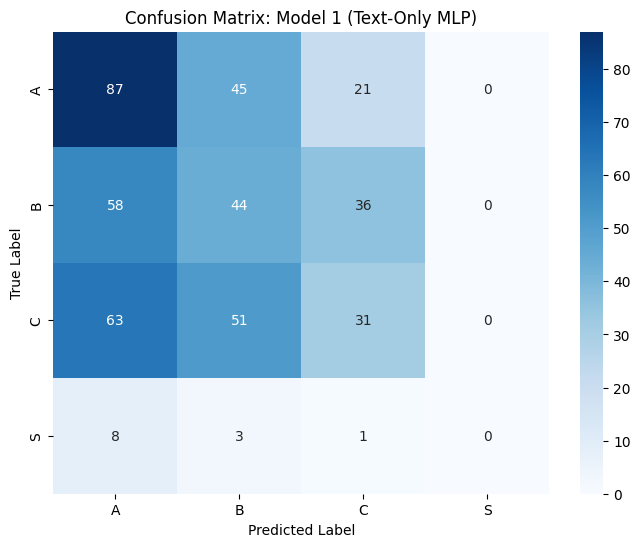

In [ ]:
# ==========================================
# 1. データの準備
# ==========================================
# df_merged から Hugging Faceベクトル（tfidf_vec_以外で_vec_がつくもの）を抽出
hf_cols = [c for c in df_merged.columns if '_vec_' in c and not c.startswith('tfidf_vec_')]
X_text = df_merged[hf_cols].fillna(0).to_numpy(dtype=np.float32)

# ラベルの準備
le = LabelEncoder()
y = le.fit_transform(df_merged['revenue_class'])
y = np.array(y, dtype=np.int32)
num_classes = len(le.classes_)

print("--- Data Info ---")
print(f"X_text shape: {X_text.shape}")
print(f"Classes     : {le.classes_}")

# ==========================================
# 2. モデル構築関数
# ==========================================
def build_model_1(input_dim, num_classes):
    """モデル1: テキストベクトルのみのシンプルなMLP"""
    inputs = keras.Input(shape=(input_dim,), name="text_vectors")
    
    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ==========================================
# 3. K-Fold 交差検証 (学習と予測)
# ==========================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

all_y_true_m1 = []
all_y_pred_m1 = []
fold_accuracies_m1 = []

print("\n🚀 Training Model 1: Text-Only MLP...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    # データの分割
    X_train, X_val = X_text[train_idx], X_text[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # モデルの初期化
    model = build_model_1(X_text.shape[1], num_classes)
    
    # 早期終了の設定（過学習対策）
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    # 学習の実行
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0 # ログが長くなるので非表示
    )

    # 予測
    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 結果を保存
    all_y_true_m1.extend(y_val.tolist())
    all_y_pred_m1.extend(y_pred.tolist())
    
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies_m1.append(acc)
    print(f" - Fold {fold + 1}/{n_splits} Accuracy: {acc:.4f}")

# ==========================================
# 4. 結果の評価と可視化
# ==========================================
avg_acc_m1 = np.mean(fold_accuracies_m1)
macro_f1_m1 = f1_score(all_y_true_m1, all_y_pred_m1, average='macro')

print("\n" + "="*40)
print("🏆 Model 1 Evaluation Report")
print("="*40)
print(f"Average Accuracy: {avg_acc_m1:.4f} (± {np.std(fold_accuracies_m1):.4f})")
print(f"Macro F1 Score  : {macro_f1_m1:.4f}")
print("\n" + classification_report(all_y_true_m1, all_y_pred_m1, target_names=le.classes_)) # type: ignore

# 混同行列の描画
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_y_true_m1, all_y_pred_m1), annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_) # type: ignore
plt.title('Confusion Matrix: Model 1 (Text-Only)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## モデル2: テキスト＋構造特徴量 統合モデル

このモデルは2つの異なる特徴量ソースを活用します:

- **テキストベクトル入力**: HuggingFace埋め込みまたはTF-IDFベクトル
  - Dense層で圧縮・抽象化
  - BatchNormalizationで安定化
  - Dropoutで過学習を防止

- **構造特徴量入力**: 企業情報（設立年、従業員数など）
  - Dense層で数値特徴を学習
  - テキスト側より浅い構造

- **結合・分類部**: 両者をConcatenateして統合
  - 共通の隠れ層で相互作用を学習
  - 最終的にクラス確率を出力

**利点**: テキストと構造情報の両方を活用して精度向上を期待


--- Data Info (Model 2) ---
X_text shape  : (448, 5376)
X_struct shape: (448, 38)
Struct columns extracted: 38 features

🚀 Training Model 2: Late Fusion (Text + Struct)...


 - Fold 1/5 Accuracy: 0.5333


 - Fold 2/5 Accuracy: 0.4667


 - Fold 3/5 Accuracy: 0.3667


 - Fold 4/5 Accuracy: 0.3820
 - Fold 5/5 Accuracy: 0.4270

🏆 Model 2 Evaluation Report
Average Accuracy: 0.4351 (± 0.0604)
Macro F1 Score  : 0.3230

              precision    recall  f1-score   support

           A       0.49      0.63      0.55       153
           B       0.37      0.35      0.36       138
           C       0.42      0.35      0.38       145
           S       0.00      0.00      0.00        12

    accuracy                           0.44       448
   macro avg       0.32      0.33      0.32       448
weighted avg       0.42      0.44      0.42       448



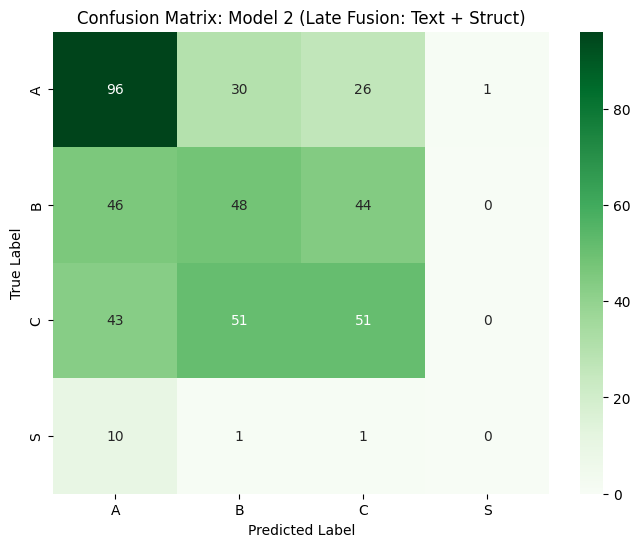

In [ ]:
# ==========================================
# 1. 追加特徴量（構造＋キーワード）の準備
# ==========================================
# df_merged から、テキストベクトルとTF-IDF、および不要なメタデータ"以外"の数値カラムを抽出
struct_cols = [
    c for c in df_merged.columns 
    if not c.startswith('tfidf_vec_') 
    and '_vec_' not in c 
    and c not in ['company_name', 'revenue_class', 'url', 'page_category']
    and pd.api.types.is_numeric_dtype(df_merged[c]) # 数値型のみ
]

X_struct = df_merged[struct_cols].fillna(0).to_numpy(dtype=np.float32)

print("--- Data Info (Model 2) ---")
print(f"X_text shape  : {X_text.shape}")
print(f"X_struct shape: {X_struct.shape}")
print(f"Struct columns extracted: {len(struct_cols)} features")

# ==========================================
# 2. モデル構築関数 (Two-Tower Architecture)
# ==========================================
def build_model_2(text_dim, struct_dim, num_classes):
    """モデル2: テキストと追加特徴量を独立して処理した後に結合するMLP"""
    
    # --- 入力層 ---
    text_input = keras.Input(shape=(text_dim,), name="text_vectors")
    struct_input = keras.Input(shape=(struct_dim,), name="structural_features")
    
    # --- テキスト処理用MLP ---
    x_text = layers.Dense(256, activation="relu")(text_input)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)

    x_text = layers.Dense(64, activation="relu")(x_text)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)
    
    # --- 構造・キーワード処理用MLP ---
    x_struct = layers.Dense(64, activation="relu")(struct_input)
    x_struct = layers.BatchNormalization()(x_struct)
    x_struct = layers.Dropout(0.2)(x_struct)
    
    # --- 結合 (Late Fusion) ---
    combined = layers.Concatenate(name="late_fusion")([x_text, x_struct])
    
    # --- 結合後のMLP ---
    z = layers.Dense(256, activation="relu")(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)
    
    outputs = layers.Dense(num_classes, activation="softmax")(z)
    
    model = keras.Model(inputs=[text_input, struct_input], outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ==========================================
# 3. K-Fold 交差検証 (学習と予測)
# ==========================================
all_y_true_m2 = []
all_y_pred_m2 = []
fold_accuracies_m2 = []

print("\n🚀 Training Model 2: Late Fusion (Text + Struct)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    # データの分割
    X_text_train, X_text_val = X_text[train_idx], X_text[val_idx]
    X_struct_train, X_struct_val = X_struct[train_idx], X_struct[val_idx]
    y_train, y_val = y[train_idx], y[val_idx] # type: ignore

    # ★重要: 構造的特徴量はスケールがバラバラ（文字数や比率など）なので標準化する
    # 情報漏洩（リーク）を防ぐため、Foldのtrainデータのみでfitする
    scaler = StandardScaler()
    X_struct_train_scaled = scaler.fit_transform(X_struct_train)
    X_struct_val_scaled = scaler.transform(X_struct_val)

    # モデルの初期化
    model = build_model_2(X_text.shape[1], X_struct.shape[1], num_classes)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    # 学習 (入力を辞書型で渡す)
    model.fit(
        {"text_vectors": X_text_train, "structural_features": X_struct_train_scaled},
        y_train, # type: ignore
        validation_data=(
            {"text_vectors": X_text_val, "structural_features": X_struct_val_scaled},
            y_val
        ), # type: ignore
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # 予測
    y_pred_prob = model.predict(
        {"text_vectors": X_text_val, "structural_features": X_struct_val_scaled},  # type: ignore
        verbose=0
    )
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 結果を保存
    all_y_true_m2.extend(y_val.tolist()) # type: ignore
    all_y_pred_m2.extend(y_pred.tolist())
    
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies_m2.append(acc)
    print(f" - Fold {fold + 1}/{n_splits} Accuracy: {acc:.4f}")

# ==========================================
# 4. 結果の評価と可視化
# ==========================================
avg_acc_m2 = np.mean(fold_accuracies_m2)
macro_f1_m2 = f1_score(all_y_true_m2, all_y_pred_m2, average='macro')

print("\n" + "="*40)
print("🏆 Model 2 Evaluation Report")
print("="*40)
print(f"Average Accuracy: {avg_acc_m2:.4f} (± {np.std(fold_accuracies_m2):.4f})")
print(f"Macro F1 Score  : {macro_f1_m2:.4f}")
print("\n" + classification_report(all_y_true_m2, all_y_pred_m2, target_names=le.classes_)) # type: ignore

# 混同行列の描画
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_y_true_m2, all_y_pred_m2), annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_) # type: ignore
plt.title('Confusion Matrix: Model 2 (Late Fusion: Text + keyword)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## モデル2-2 テキスト＋TF-IDF特徴量 統合モデル

--- Data Info (Model 2: TF-IDF Late Fusion) ---
X_text shape  : (448, 5376)
X_tfidf shape : (448, 500)

🚀 Training Model 2: Late Fusion (Text + TF-IDF)...


 - Fold 1/5 Accuracy: 0.3111


 - Fold 2/5 Accuracy: 0.3889


 - Fold 3/5 Accuracy: 0.3333


 - Fold 4/5 Accuracy: 0.3708
 - Fold 5/5 Accuracy: 0.3034

🏆 Model 2 Evaluation Report
Average Accuracy: 0.3415 (± 0.0333)
Macro F1 Score  : 0.2547

              precision    recall  f1-score   support

           A       0.34      0.35      0.35       153
           B       0.32      0.24      0.27       138
           C       0.36      0.46      0.40       145
           S       0.00      0.00      0.00        12

    accuracy                           0.34       448
   macro avg       0.25      0.26      0.25       448
weighted avg       0.33      0.34      0.33       448



/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/haru/Documents/GitHub/panta-rhai-assignment/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

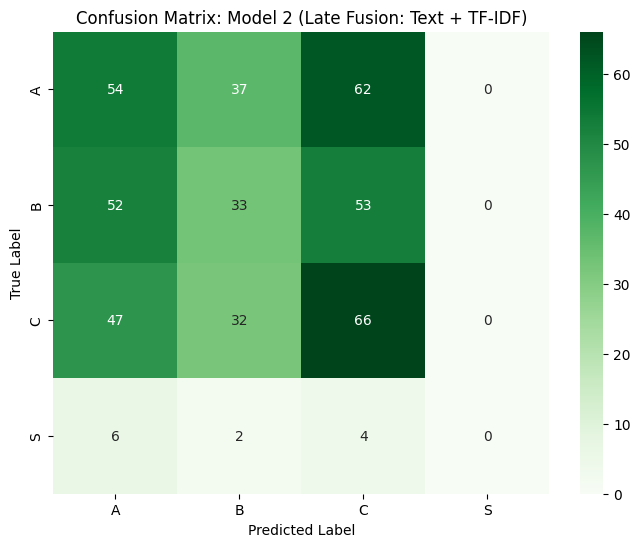

In [ ]:
# ==========================================
# 1. 追加特徴量（TF-IDF）の準備
# ==========================================
# df_merged から TF-IDFベクトルを抽出（X_textはモデル1で作成済みと想定）
tfidf_cols = [c for c in df_merged.columns if c.startswith('tfidf_vec_')]
X_tfidf = df_merged[tfidf_cols].fillna(0).to_numpy(dtype=np.float32)

print("--- Data Info (Model 2: TF-IDF Late Fusion) ---")
print(f"X_text shape  : {X_text.shape}")
print(f"X_tfidf shape : {X_tfidf.shape}")

# ==========================================
# 2. モデル構築関数 (Two-Tower Architecture)
# ==========================================
def build_model_2(text_dim, tfidf_dim, num_classes):
    """モデル2: テキスト(HF)とTF-IDFを独立して処理した後に結合するMLP"""
    
    # --- 入力層 ---
    text_input = keras.Input(shape=(text_dim,), name="text_vectors")
    tfidf_input = keras.Input(shape=(tfidf_dim,), name="tfidf_vectors")
    
    # --- テキスト処理用MLP ---
    x_text = layers.Dense(256, activation="relu")(text_input)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)

    x_text = layers.Dense(64, activation="relu")(x_text)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)
    
    # --- TF-IDF処理用MLP ---
    x_tfidf = layers.Dense(128, activation="relu")(tfidf_input)
    x_tfidf = layers.BatchNormalization()(x_tfidf)
    x_tfidf = layers.Dropout(0.3)(x_tfidf)
    
    # --- 結合 (Late Fusion) ---
    combined = layers.Concatenate(name="late_fusion")([x_text, x_tfidf])
    
    # --- 結合後のMLP ---
    z = layers.Dense(128, activation="relu")(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)
    
    outputs = layers.Dense(num_classes, activation="softmax")(z)
    
    model = keras.Model(inputs=[text_input, tfidf_input], outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ==========================================
# 3. K-Fold 交差検証 (学習と予測)
# ==========================================
all_y_true_m2 = []
all_y_pred_m2 = []
fold_accuracies_m2 = []

n_splits = 5 # skfの分割数に合わせてください

print("\n🚀 Training Model 2: Late Fusion (Text + TF-IDF)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    # データの分割
    X_text_train, X_text_val = X_text[train_idx], X_text[val_idx]
    X_tfidf_train, X_tfidf_val = X_tfidf[train_idx], X_tfidf[val_idx]
    y_train, y_val = y[train_idx], y[val_idx] # type: ignore

    # モデルの初期化
    model = build_model_2(X_text.shape[1], X_tfidf.shape[1], num_classes)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    # 学習 (入力を辞書型で渡す)
    model.fit(
        {"text_vectors": X_text_train, "tfidf_vectors": X_tfidf_train},
        y_train, # type: ignore
        validation_data=(
            {"text_vectors": X_text_val, "tfidf_vectors": X_tfidf_val},
            y_val
        ), # type: ignore
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # 予測
    y_pred_prob = model.predict(
        {"text_vectors": X_text_val, "tfidf_vectors": X_tfidf_val},  # type: ignore
        verbose=0
    )
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 結果を保存
    all_y_true_m2.extend(y_val.tolist()) # type: ignore
    all_y_pred_m2.extend(y_pred.tolist())
    
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies_m2.append(acc)
    print(f" - Fold {fold + 1}/{n_splits} Accuracy: {acc:.4f}")

# ==========================================
# 4. 結果の評価と可視化
# ==========================================
avg_acc_m2 = np.mean(fold_accuracies_m2)
macro_f1_m2 = f1_score(all_y_true_m2, all_y_pred_m2, average='macro')

print("\n" + "="*40)
print("🏆 Model 2 Evaluation Report")
print("="*40)
print(f"Average Accuracy: {avg_acc_m2:.4f} (± {np.std(fold_accuracies_m2):.4f})")
print(f"Macro F1 Score  : {macro_f1_m2:.4f}")
print("\n" + classification_report(all_y_true_m2, all_y_pred_m2, target_names=le.classes_)) # type: ignore

# 混同行列の描画
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_y_true_m2, all_y_pred_m2), annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_) # type: ignore
plt.title('Confusion Matrix: Model 2 (Late Fusion: Text + TF-IDF)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## モデル3: ゲーティング機構付きテキストモデル

アテンション機構を使った高度なモデルです:

- **入力**: テキストベクトル + TF-IDFベクトル（両テキストベース）
- **ゲーティング機構**:
  - TF-IDFベクトルを「鍵」として使用
  - Sigmoid活性化のDense層でゲート値（0.0～1.0）を生成
  - HFベクトルに要素ごとに乗算（フィルタリング）
  
- **分析フロー**: 
  1. TF-IDFが関連度の高いテキスト要素を動的に選別
  2. 選別されたHFベクトルとTF-IDFを結合
  3. 統合モデルと同じ分類ヘッドで予測

**利点**: テキスト同士の相互作用を明示的に学習  
**特性**: 動的なアテンション機構で最適な特徴量の重み付けが自動学習される

In [1]:
# ==========================================
# 1. TF-IDF特徴量の準備
# ==========================================
# df_merged から TF-IDFベクトルを抽出（X_textはモデル1で作成済み）
tfidf_cols = [c for c in df_merged.columns if c.startswith('tfidf_vec_')]
X_tfidf = df_merged[tfidf_cols].fillna(0).to_numpy(dtype=np.float32)

print("--- Data Info (Model 3) ---")
print(f"X_text shape : {X_text.shape} (Hugging Face Vectors)")
print(f"X_tfidf shape: {X_tfidf.shape} (TF-IDF Gate Vectors)")

# ==========================================
# 2. モデル構築関数 (Gated Fusion Architecture)
# ==========================================
def build_model_3(hf_dim, tfidf_dim, num_classes):
    """モデル3: TF-IDFをゲートとして使い、テキストベクトルをフィルタリングするMLP"""
    
    # --- 入力層 ---
    hf_input = keras.Input(shape=(hf_dim,), name="text_vectors")
    tfidf_input = keras.Input(shape=(tfidf_dim,), name="tfidf_vectors")
    
    # --- ゲーティング機構 (Attention Mechanism) ---
    # TF-IDF (500次元) から、HFベクトルと同じ次元数の「ゲート（0.0〜1.0）」を作成
    gate = layers.Dense(hf_dim, activation="sigmoid", name="attention_gate")(tfidf_input)
    
    # HFベクトルにゲートを掛け算して、不要な文脈ノイズを遮断
    gated_hf = layers.Multiply(name="gated_hf")([hf_input, gate])
    
    # --- 予測ヘッド ---
    # 洗練されたHF文脈と、元のTF-IDFキーワード情報を結合はせず、ゲートでフィルタリングされたHFベクトルのみを使う
    #combined = layers.Concatenate(name="fusion")([gated_hf, tfidf_input])
    
    z = layers.Dense(512, activation="relu")(gated_hf)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)
    
    z = layers.Dense(128, activation="relu")(gated_hf)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)

    outputs = layers.Dense(num_classes, activation="softmax")(z)
    
    model = keras.Model(inputs=[hf_input, tfidf_input], outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ==========================================
# 3. K-Fold 交差検証 (学習と予測)
# ==========================================
all_y_true_m3 = []
all_y_pred_m3 = []
fold_accuracies_m3 = []

print("\n🚀 Training Model 3: Gated Fusion (HF + TF-IDF Gate)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    # データの分割
    X_text_train, X_text_val = X_text[train_idx], X_text[val_idx]
    X_tfidf_train, X_tfidf_val = X_tfidf[train_idx], X_tfidf[val_idx]
    y_train, y_val = y[train_idx], y[val_idx] # type: ignore

    # モデルの初期化
    model = build_model_3(X_text.shape[1], X_tfidf.shape[1], num_classes)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    # 学習 (HFベクトルとTF-IDFの2つを入力)
    model.fit(
        {"text_vectors": X_text_train, "tfidf_vectors": X_tfidf_train},
        y_train, # type: ignore
        validation_data=(
            {"text_vectors": X_text_val, "tfidf_vectors": X_tfidf_val},
            y_val
        ), # type: ignore
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # 予測
    y_pred_prob = model.predict(
        {"text_vectors": X_text_val, "tfidf_vectors": X_tfidf_val},  # type: ignore
        verbose=0
    )
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 結果を保存
    all_y_true_m3.extend(y_val.tolist()) # type: ignore
    all_y_pred_m3.extend(y_pred.tolist())
    
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies_m3.append(acc)
    print(f" - Fold {fold + 1}/{n_splits} Accuracy: {acc:.4f}")

# ==========================================
# 4. 結果の評価と可視化
# ==========================================
avg_acc_m3 = np.mean(fold_accuracies_m3)
macro_f1_m3 = f1_score(all_y_true_m3, all_y_pred_m3, average='macro')

print("\n" + "="*40)
print("🏆 Model 3 Evaluation Report")
print("="*40)
print(f"Average Accuracy: {avg_acc_m3:.4f} (± {np.std(fold_accuracies_m3):.4f})")
print(f"Macro F1 Score  : {macro_f1_m3:.4f}")
print("\n" + classification_report(all_y_true_m3, all_y_pred_m3, target_names=le.classes_)) # type: ignore

# 混同行列の描画
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_y_true_m3, all_y_pred_m3), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=le.classes_, yticklabels=le.classes_) # type: ignore
plt.title('Confusion Matrix: Model 3 (Gated Fusion: Text + TF-IDF)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

NameError: name 'df_merged' is not defined

## モデル４　ゲーティング＋構造特徴

--- Data Info (Model 3) ---
X_text shape : (448, 5376) (Hugging Face Vectors)
X_tfidf shape: (448, 500) (TF-IDF Gate Vectors)

🚀 Training Model 3: Gated Fusion (HF + TF-IDF Gate)...


 - Fold 1/5 Accuracy: 0.2222


 - Fold 2/5 Accuracy: 0.3333


 - Fold 3/5 Accuracy: 0.1000


 - Fold 4/5 Accuracy: 0.2584
 - Fold 5/5 Accuracy: 0.2697

🏆 Model 3 Evaluation Report
Average Accuracy: 0.2367 (± 0.0772)
Macro F1 Score  : 0.1845

              precision    recall  f1-score   support

           A       0.34      0.48      0.40       153
           B       0.25      0.12      0.17       138
           C       0.27      0.08      0.13       145
           S       0.03      0.25      0.05        12

    accuracy                           0.24       448
   macro avg       0.22      0.23      0.18       448
weighted avg       0.28      0.24      0.23       448



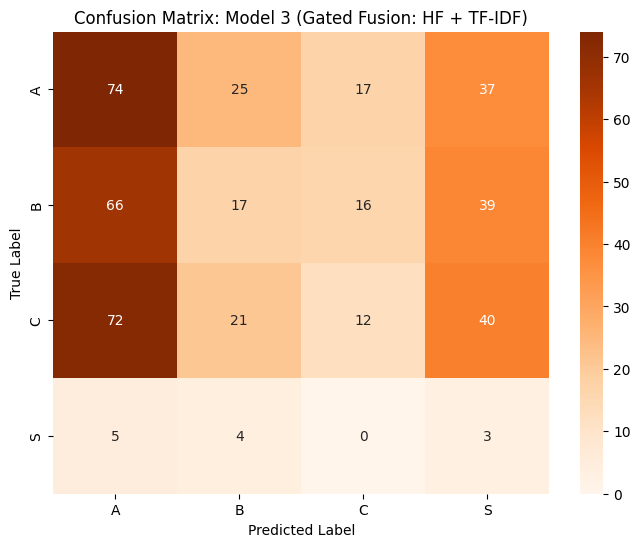

In [ ]:
# ==========================================
# 1. TF-IDF特徴量の準備
# ==========================================
# df_merged から TF-IDFベクトルを抽出（X_textはモデル1で作成済み）
tfidf_cols = [c for c in df_merged.columns if c.startswith('tfidf_vec_')]
X_tfidf = df_merged[tfidf_cols].fillna(0).to_numpy(dtype=np.float32)

print("--- Data Info (Model 3) ---")
print(f"X_text shape : {X_text.shape} (Hugging Face Vectors)")
print(f"X_tfidf shape: {X_tfidf.shape} (TF-IDF Gate Vectors)")

# ==========================================
# 2. モデル構築関数 (Gated Fusion Architecture)
# ==========================================
def build_model_3(hf_dim, tfidf_dim, struct_dim, num_classes):
    """モデル3: TF-IDFをゲートとして使い、テキストベクトルをフィルタリングするMLP"""
    
    # --- 入力層 ---
    hf_input = keras.Input(shape=(hf_dim,), name="text_vectors")
    tfidf_input = keras.Input(shape=(tfidf_dim,), name="tfidf_vectors")
    struct_input = keras.Input(shape=(struct_dim,), name="structural_features") 

    # --- ゲーティング機構 (Attention Mechanism) ---
    # TF-IDF (500次元) から、HFベクトルと同じ次元数の「ゲート（0.0〜1.0）」を作成
    gate = layers.Dense(hf_dim, activation="sigmoid", name="attention_gate")(tfidf_input)
    
    # HFベクトルにゲートを掛け算して、不要な文脈ノイズを遮断
    gated_hf = layers.Multiply(name="gated_hf")([hf_input, gate])
    
    
    # --- テキスト処理用MLP ---
    x_text = layers.Dense(256, activation="relu")(hf_input)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)

    x_text = layers.Dense(64, activation="relu")(x_text)
    x_text = layers.BatchNormalization()(x_text)
    x_text = layers.Dropout(0.3)(x_text)
    
    # --- 構造・キーワード処理用MLP ---
    x_struct = layers.Dense(64, activation="relu")(struct_input)
    x_struct = layers.BatchNormalization()(x_struct)
    x_struct = layers.Dropout(0.2)(x_struct)
    
    # --- 結合 (Late Fusion) ---
    combined = layers.Concatenate(name="late_fusion")([x_text, x_struct])
    
    # --- 結合後のMLP ---
    z = layers.Dense(256, activation="relu")(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(64, activation="relu")(z)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)

    outputs = layers.Dense(num_classes, activation="softmax")(z)
    
    model = keras.Model(inputs=[hf_input, tfidf_input, struct_input], outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ==========================================
# 3. K-Fold 交差検証 (学習と予測)
# ==========================================
all_y_true_m3 = []
all_y_pred_m3 = []
fold_accuracies_m3 = []

print("\n🚀 Training Model 3: Gated Fusion (HF + TF-IDF Gate)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    # データの分割
    X_text_train, X_text_val = X_text[train_idx], X_text[val_idx]
    X_tfidf_train, X_tfidf_val = X_tfidf[train_idx], X_tfidf[val_idx]
    X_struct_train, X_struct_val = X_struct[train_idx], X_struct[val_idx]
    y_train, y_val = y[train_idx], y[val_idx] # type: ignore

    scaler = StandardScaler()
    X_struct_train_scaled = scaler.fit_transform(X_struct_train)
    X_struct_val_scaled = scaler.transform(X_struct_val)

    # モデルの初期化
    model = build_model_3(X_text.shape[1], X_tfidf.shape[1], X_struct.shape[1], num_classes)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    # 学習 (HFベクトルとTF-IDFの2つを入力)
    model.fit(
        {"text_vectors": X_text_train,
         "tfidf_vectors": X_tfidf_train,
         "structural_features": X_struct_train_scaled
        },         
        y_train, # type: ignore
        validation_data=(
            {"text_vectors": X_text_val,
             "tfidf_vectors": X_tfidf_val,
             "structural_features": X_struct_val_scaled
            },
            y_val
        ), # type: ignore
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # 予測
    y_pred_prob = model.predict(
        {"text_vectors": X_text_val, "tfidf_vectors": X_tfidf_val, "structural_features": X_struct_val},  # type: ignore
        verbose=0
    )
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 結果を保存
    all_y_true_m3.extend(y_val.tolist()) # type: ignore
    all_y_pred_m3.extend(y_pred.tolist())
    
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies_m3.append(acc)
    print(f" - Fold {fold + 1}/{n_splits} Accuracy: {acc:.4f}")

# ==========================================
# 4. 結果の評価と可視化
# ==========================================
avg_acc_m3 = np.mean(fold_accuracies_m3)
macro_f1_m3 = f1_score(all_y_true_m3, all_y_pred_m3, average='macro')

print("\n" + "="*40)
print("🏆 Model 3 Evaluation Report")
print("="*40)
print(f"Average Accuracy: {avg_acc_m3:.4f} (± {np.std(fold_accuracies_m3):.4f})")
print(f"Macro F1 Score  : {macro_f1_m3:.4f}")
print("\n" + classification_report(all_y_true_m3, all_y_pred_m3, target_names=le.classes_)) # type: ignore

# 混同行列の描画
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_y_true_m3, all_y_pred_m3), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=le.classes_, yticklabels=le.classes_) # type: ignore
plt.title('Confusion Matrix: Model 3 (HF + TF-IDF Gating)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()